In [6]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\ashwi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [7]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from scipy.stats import zscore
import scipy.stats

import seaborn as sns



# vectors

In [2]:
u = np.array([3,5])
v = np.array([8,2])

# Calculate the length of u
np.linalg.norm(u)

5.830951894845301

In [3]:
# direction of u
u / np.linalg.norm(u)

array([0.51449576, 0.85749293])

In [4]:
# norm of direction vector is 1
np.linalg.norm(u / np.linalg.norm(u))

0.9999999999999999

In [5]:
# dot product of u and v
# The dot product of two vectors u and v is calculated as the sum of the products of their corresponding components. 
# In this case, it would be (3*8) + (5*2) = 24 + 10 = 34.
# dot product is projection of one vector onto another
np.dot(u, v)



# dot procuct of u and v is same as norm of u times norm of v times cosine of angle between them
theeta = 45
theeta = math.radians(theeta)
# math.acos(np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v)))

np.linalg.norm(u) * np.linalg.norm(v) * math.cos(theeta)

34.00000000000001

In [6]:
np.dot(u, v)
 

34

# Matrices

- Basis vectors are unit length vectors parallel to the axis
- direction vector is unit vector that defines direction
- When the product of a square matrix and its transpose
gives an identity matrix, then the square matrix is known
as orthogonal matrix.
    - if (np.linalg.inv(A) == A.T): then matrix A is orthogonal.
    - A-1 = AT
    - The determinant of any orthogonal matrix is either +1 or −1.
- Transformations
    - Transformation matrix is a matrix that transforms one vector into another vector when multiplied to it
    - A scaling transform changes the size of an object by
expanding or contracting all vertices along the three
axes by three scalar values specified in the matrix.
    - A reflection is a transformation
that maps a figure to its reflection
image.
    - Projection Transformation maps vectors into their projections onto a subspace
    - Rotation Transformation rotates an object about one of the three coordinate axes, or any arbitrary vector
    - An identity matrix (or unit matrix) is a square matrix with ones on the main diagonal and zeros elsewhere
    - A I = A
    - A A-1 = I
- linear combination
    - Any RGB image => C1*RED + C2*GREEN + C3*BLUE
-  Row Reduced Echelon Form (RREF)
    - Uniqueness: Every matrix has a unique RREF, regardless of row operation sequence.
    - Rows of all zeros appear at the bottom.
    - Leading 1s: The first non-zero entry in each row is a 1 (called a leading 1 or pivot).
    - Staircase Pattern: Each leading 1 is to the right of the leading 1 in the row above it.
    - i can myltiply and divide all rows and add rows to each other
    - as many zeros as possible
-  If no vector of the set can be represented as combination of other vectors in the set, the set of vectors is linearly independent 
- If you can write every vector in a given space as a linear combination of some vectors and these vectors are independent of each other then we call them as basis vectors for that given space.
- A.T => A transpose
- A.transpose() => A transpose
- np.linalg.inv(A) == A.T => A is orthogonal Matrix
- A.dot(Q) => A.Q dot product
- A @ Q => Matrix multiplication
- np.linalg.det(A) => determinant of A
- np.dot(A, B) # dot product
- np.cross(A,B) # cross product
- DISTANCES - distance on the graph
    - np.linalg.norm(u) # Euclidean Distance L_2 norm
        - np.linalg.norm(u, ord=2) # Euclidean Distance L_2 norm
        - root(x1**2 + y1**2)
    - np.linalg.norm(u, ord=1) # Manhattan Distance
        - mod(x1) + mod(y1)
    - np.linalg.norm(u, ord=np.inf) # Chebyshev distance or max distance metric
        - max(x1, y1)
- cos_theta = np.dot(a,b)/[np.linalg.norm(a)*np.linalg.norm(b)] # Euclidean Distance]
- A.rref() # Row Reduced Echelon Form (RREF)

# PCA

- Standardize the data (center data - z score)
- Generate covariance matrix => A.T @ A
- Get eigenvectors and eigenvalues using above covariance matrix
- Eigenvectors are transformed principal components and eigenvalues are magnitude of variance captured
- Sort pairs in descending order and select the largest one as the first principal component


- cov(x,y) = A = A.T @ A
- (A-jI)e = 0 # A=cov matrix; e=eigen vector; j=eigen value
- det(A-jI) = 0 

In [7]:
df = pd.read_csv('./mpg_raw.csv')

In [8]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [10]:
df.dropna(inplace=True)

In [11]:
df.drop(columns=['name', 'origin'], inplace = True)

In [12]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 24.5 KB


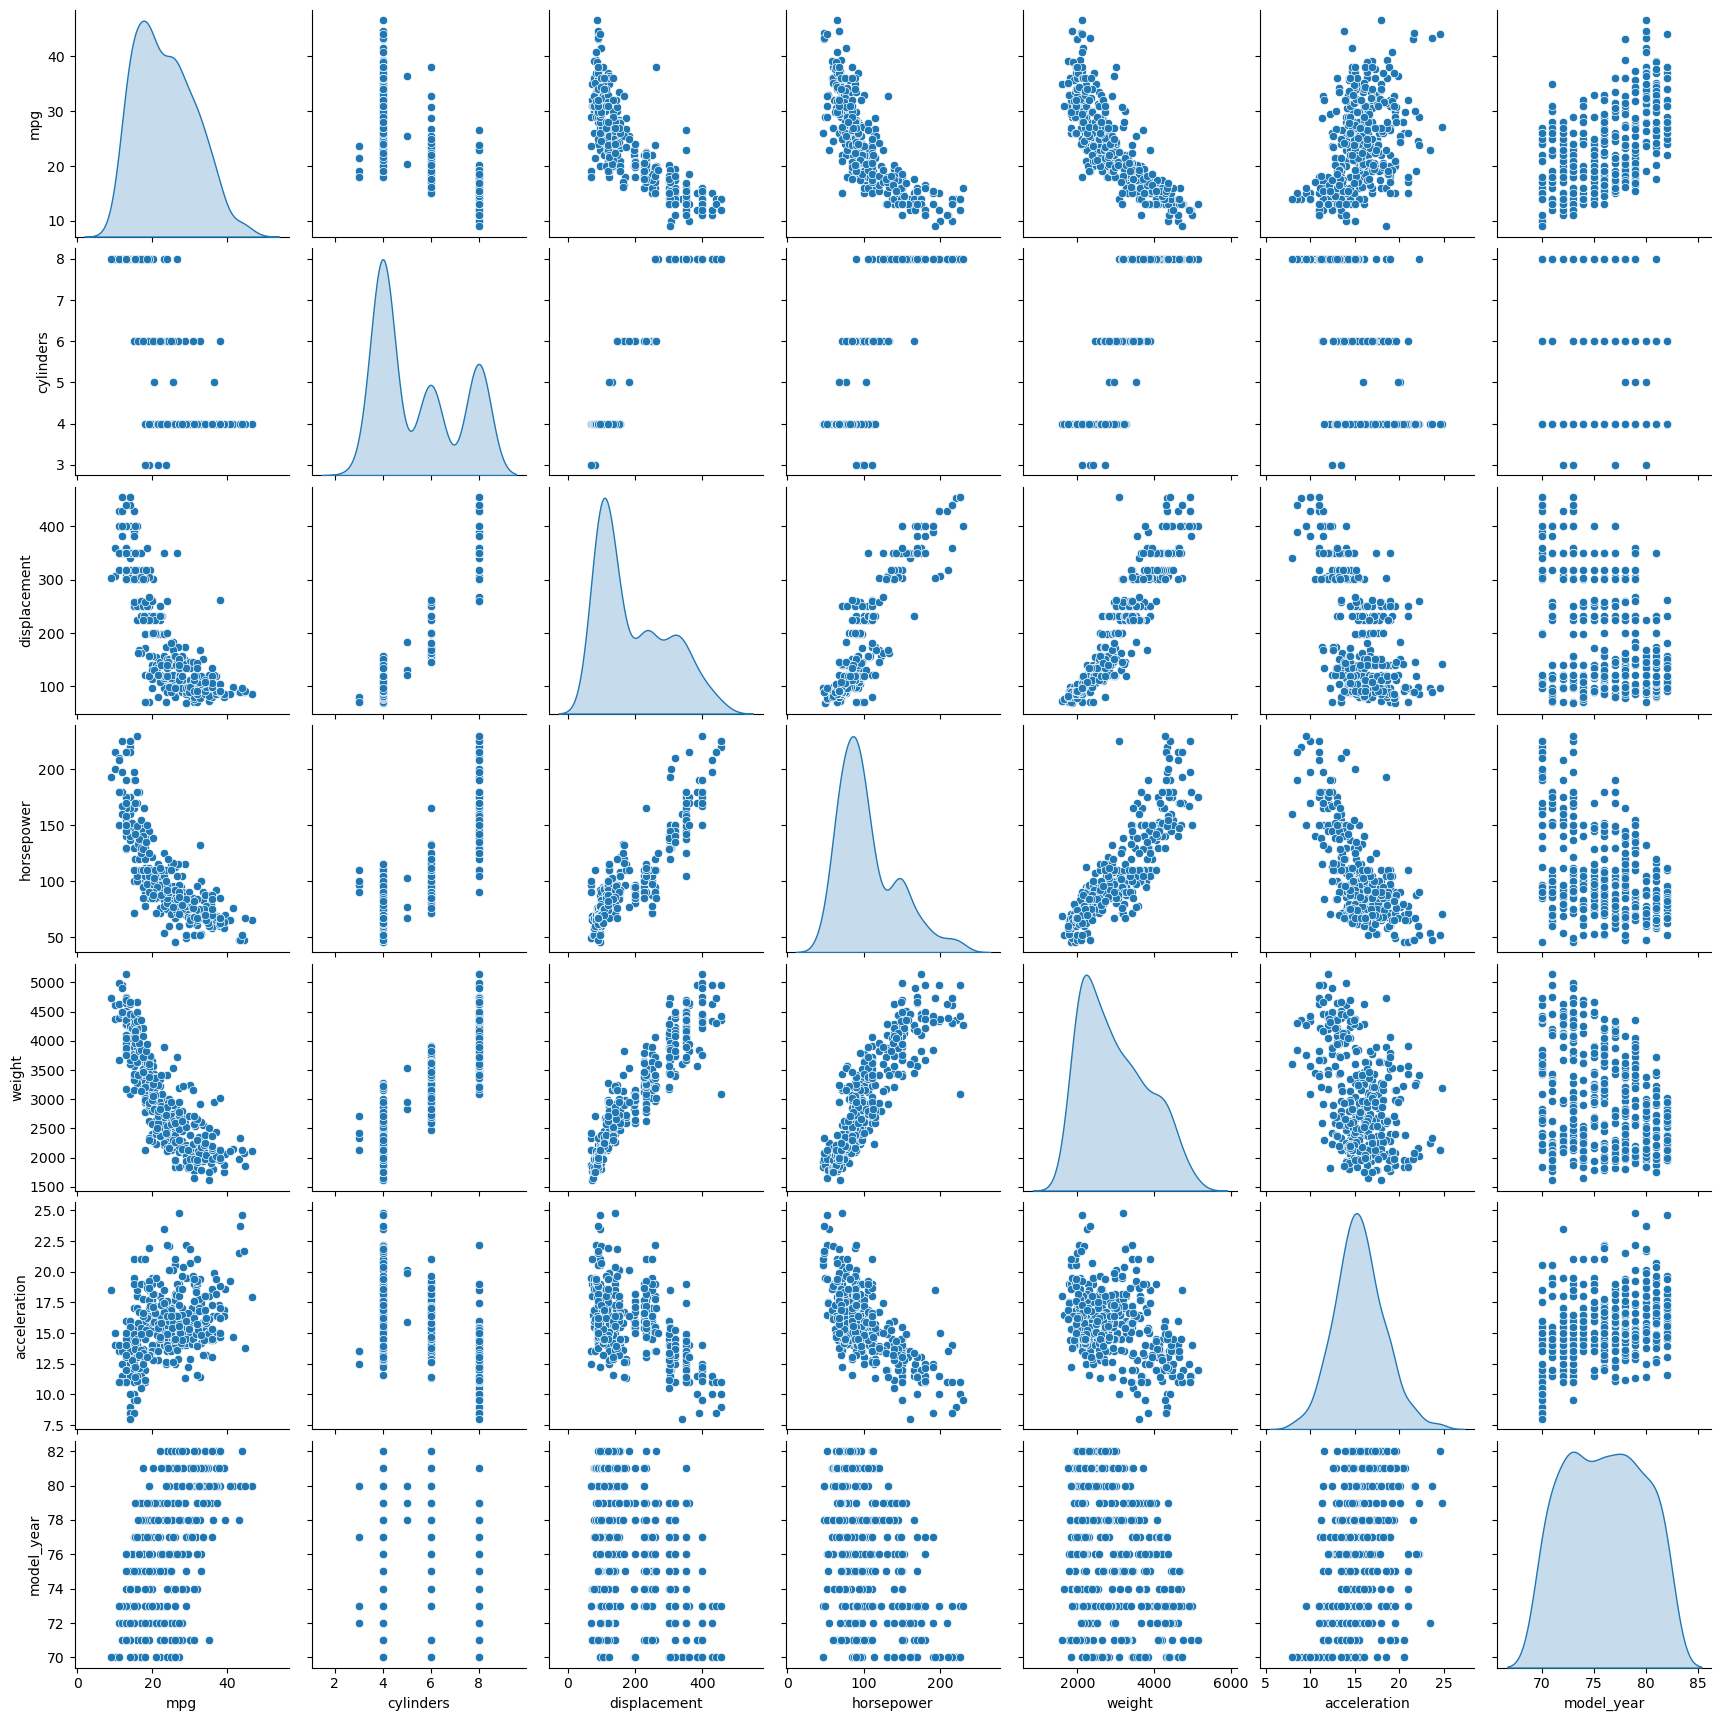

In [14]:
sns.pairplot(df, diag_kind='kde')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,-0.697747,1.482053,1.075915,0.663285,0.619748,-1.283618,-1.623241
1,-1.082115,1.482053,1.486832,1.572585,0.842258,-1.464852,-1.623241
2,-0.697747,1.482053,1.181033,1.182885,0.539692,-1.646086,-1.623241
3,-0.953992,1.482053,1.047246,1.182885,0.536160,-1.283618,-1.623241
4,-0.825870,1.482053,1.028134,0.923085,0.554997,-1.827320,-1.623241


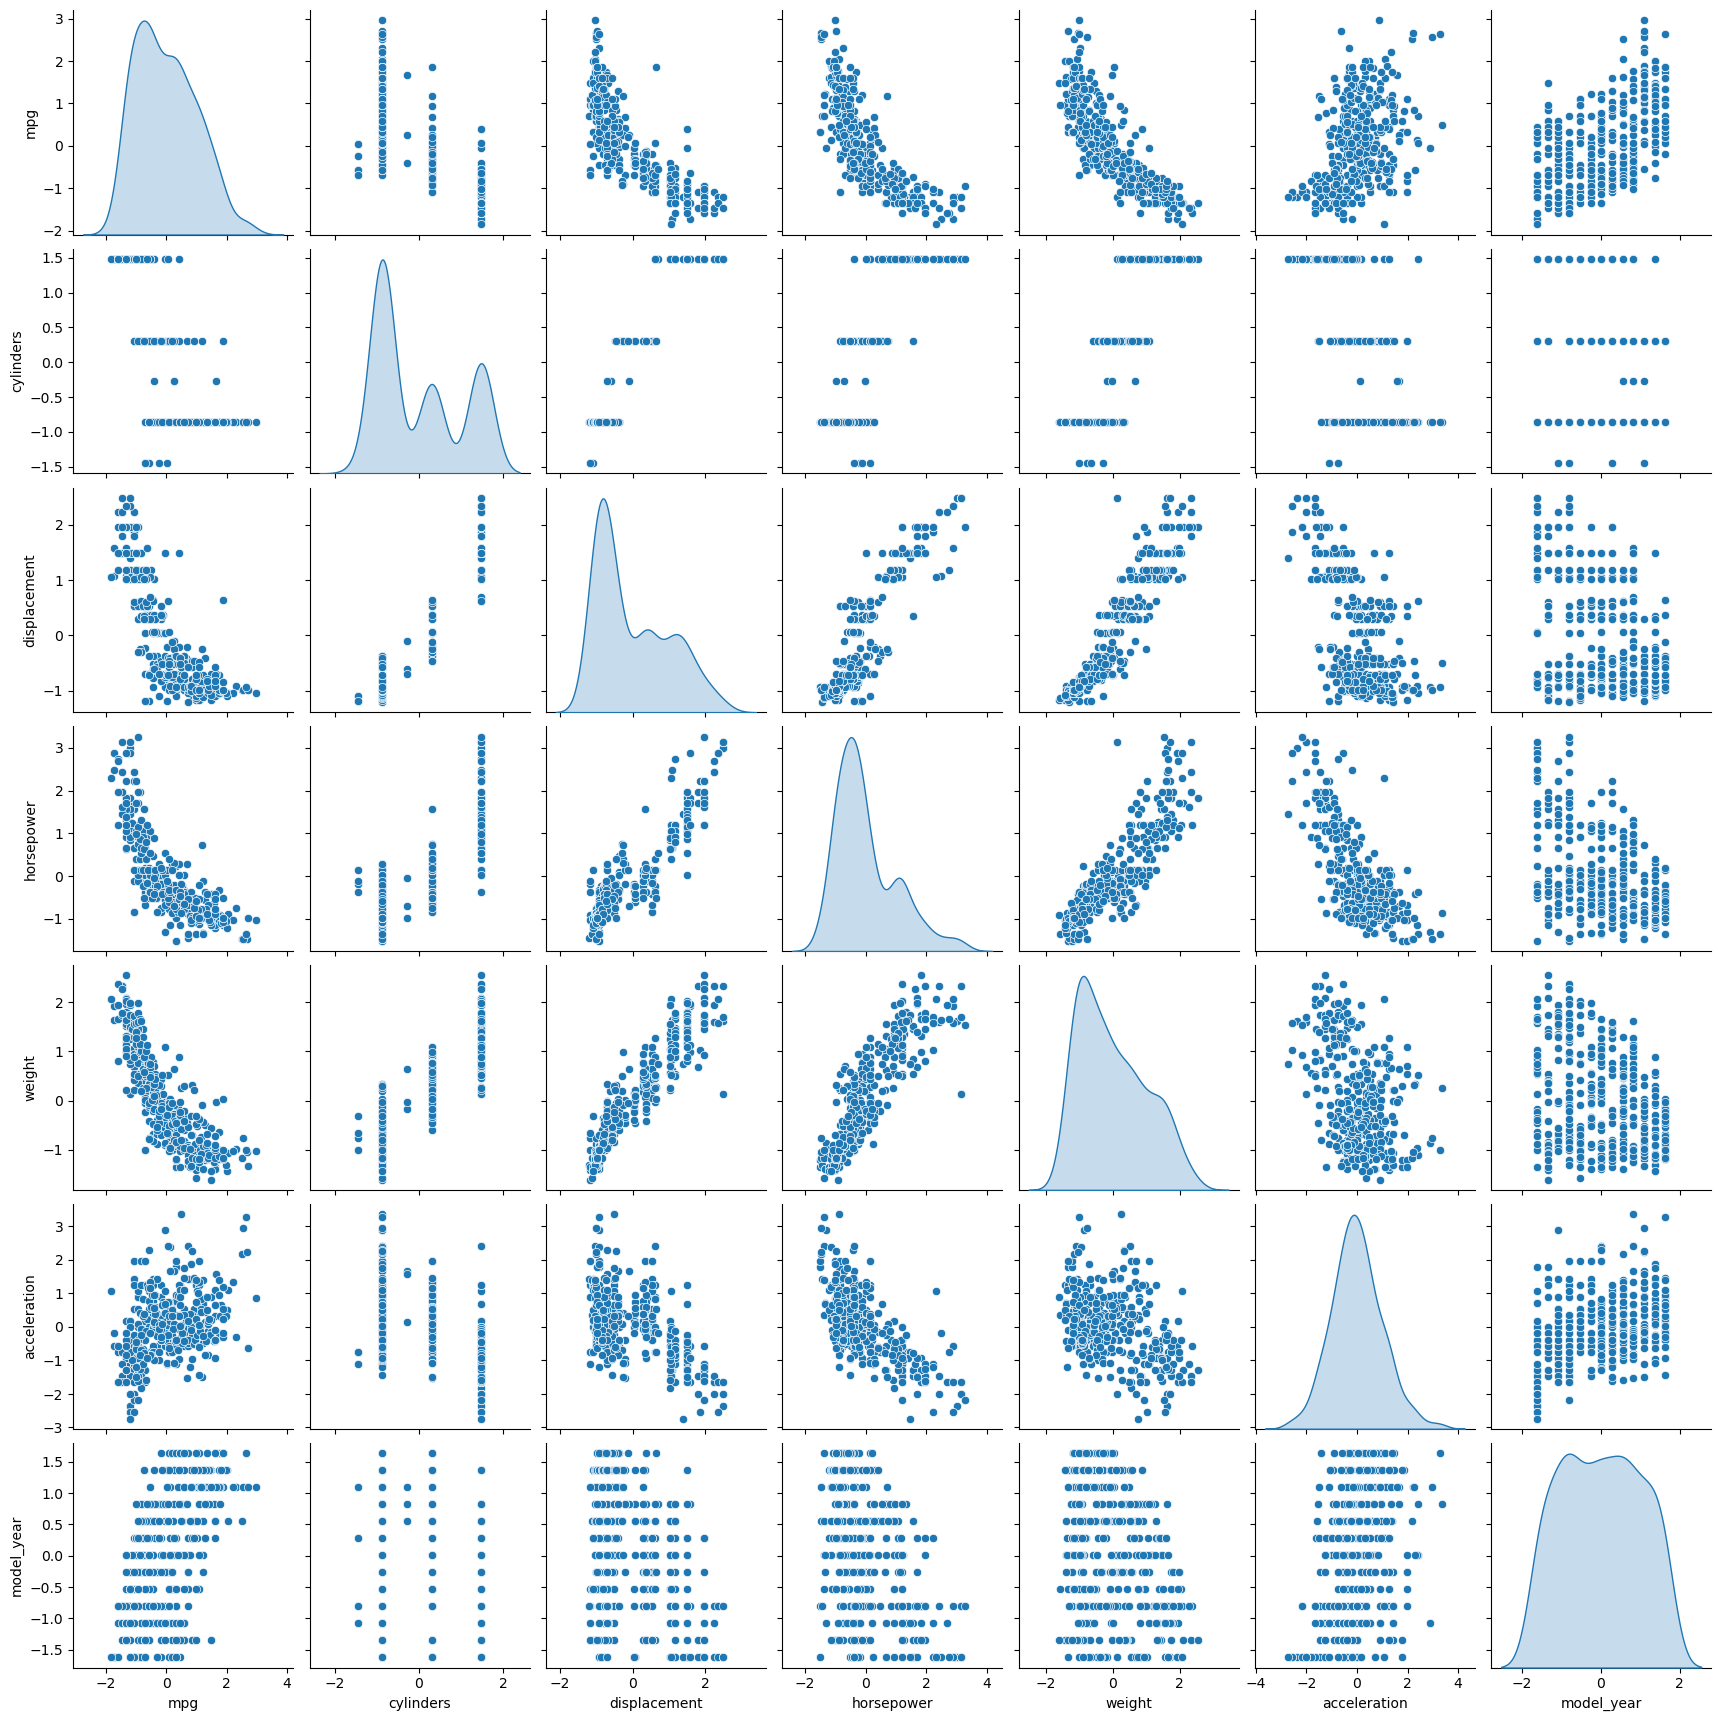

In [15]:
# centering the data using z score

df_z = df.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
sns.pairplot(df_z, diag_kind='kde')
df_z.head()


In [ ]:
cov_matrix = (df_z.T @ df_z) / (df_z.shape[0] - 1)
cov_matrix

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000


In [ ]:
y = df.mpg
X = df.drop(columns=['mpg'])
X = X.apply(lambda x: (x - x.mean()) / x.std(), axis=0) # standardize the features using z score
cov = (X.T @ X) / (X.shape[0] - 1) # covariance matrix of the standardized features
eigenvalues, eigenvectors = np.linalg.eig(cov)
eigenvalues, eigenvectors

(array([4.25715181, 0.83960969, 0.67281909, 0.13286878, 0.03637778,
        0.06117285]),
 array([[-0.45476297, -0.18949971,  0.16787927,  0.66043399, -0.46686768,
          0.27378563],
        [-0.46885724, -0.16303989,  0.13153149,  0.18824633,  0.83716918,
          0.00119299],
        [-0.46365868, -0.01052532, -0.12497783, -0.61826946, -0.10393605,
          0.61337637],
        [-0.44625213, -0.25716695,  0.27008821, -0.35122423, -0.26248935,
         -0.68521342],
        [ 0.32464331, -0.22125982,  0.86433834, -0.14811227,  0.03583935,
          0.27449654],
        [ 0.23205586, -0.90681107, -0.34477262, -0.02893841,  0.01394673,
          0.06279853]]))

In [30]:

# takes the original data X and projects it onto the new basis defined by the eigenvectors.
# I can take subset of eigenvectors to reduce dimensionality while retaining most of the variance in the data.
# (X_eigen_space = np.dot(X, eigenvectors[:k].T))

# Note that np.dot is the same as @ for 2d arrays
# np.dot is multiplication for higher dimensional matrices
# X_eigen_space = np.dot(X, eigenvectors.T)
X_eigen_space = np.dot(X, eigenvectors[0:4].T)
X_eigen_space


array([[-0.20235412, -1.74292169, -2.02680195,  0.47261826],
       [ 0.10399482, -1.80015297, -2.26350326,  0.58195645],
       [-0.01869125, -2.01023378, -2.00567697,  0.70918479],
       ...,
       [ 0.99442663, -0.91810917,  2.12031628, -0.07516786],
       [ 0.07179454,  1.28544018,  1.63414233, -0.87585068],
       [ 0.02517539,  1.56106152,  1.52521404, -0.96773975]])

In [41]:
# convert the numpy array to a pandas dataframe
eigen_df = pd.DataFrame(X_eigen_space)

x_train, x_test, y_train, y_test = train_test_split(X_eigen_space, y, test_size=0.2, random_state=42)
# sns.pairplot(eigen_df, diag_kind='kde')

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


model = LinearRegression()
model.fit(x_train, y_train)
model.coef_, model.intercept_

(array([-2.41433338, -1.08152148,  5.11222798, -0.26942629]),
 23.48512903809388)

In [33]:
model.score(x_test, y_test)

0.7914898507143611

# basis

In [ ]:
# question
# u = np.array([[2],[0]])
# v = np.array([[[1],[3]]])

basis = np.array([[2,1], [0,3]])

# vector defined in basis plane
vec = np.array([[2],[1]])

# rotate this by 45 degree

# first convert the vector to standard coordinates -> [0,1] and [1,0]
vec = basis @ vec

# rotate the vector by 45 degree in the standard coordinates
# theeta = math.radians(45)
vec = np.array([[1/(2**0.5),1/(2**0.5)], [-1/(2**0.5),1/(2**0.5)]]) @ vec

# now convert back to the original coordinates
vec = np.linalg.inv(basis) @ vec



In [ ]:
# question
# u = np.array([[2],[0]])
# v = np.array([[[1],[3]]])

basis = np.array([[2,1], [0,3]])

# vector defined in basis plane
vec = np.array([[2],[1]])

# rotate this by 45 degree

# first convert the vector to standard coordinates -> [0,1] and [1,0]
vec = np.dot(basis, vec)

# IMPORTANT: the rotation matrix for 45 degree is [[cos(45), -sin(45)], [sin(45), cos(45)]]
# rotate the vector by 45 degree in the standard coordinates
theeta = np.radians(45)
# vec = np.array([[1/(2**0.5),1/(2**0.5)], [-1/(2**0.5),1/(2**0.5)]]) @ vec
vec = np.array([[np.cos(theeta), -np.sin(theeta)], [np.sin(theeta), np.cos(theeta)]]) @ vec

# now convert back to the original coordinates
vec = np.dot(np.linalg.inv(basis), vec)

vec


array([[-0.23570226],
       [ 1.88561808]])

In [34]:
np.array([[2,0], [1,3]])

array([[2, 0],
       [1, 3]])

In [35]:
np.array([[2],[1]])

array([[2],
       [1]])

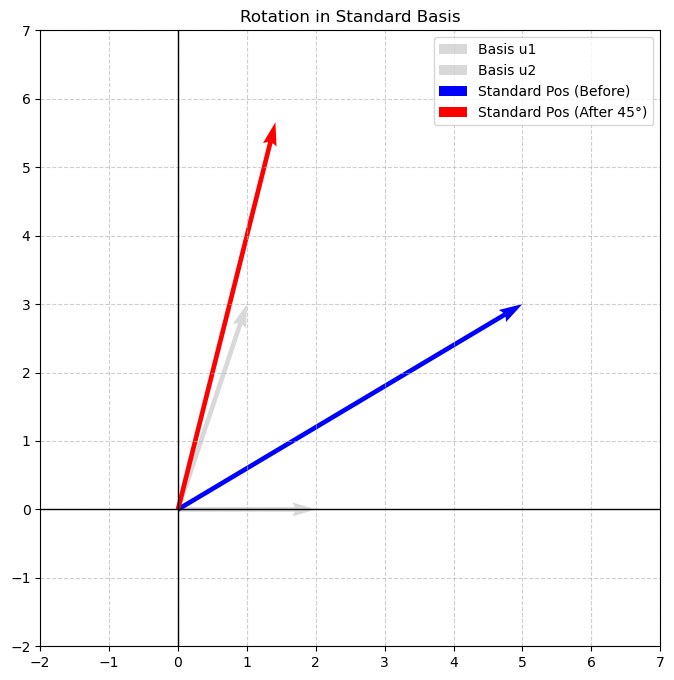

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup
basis = np.array([[2, 1], [0, 3]])
vec_in_basis = np.array([2, 1])
theta = np.radians(45)

# 2. Calculation
# Into standard basis
vec_standard = basis @ vec_in_basis

# Rotate in standard basis (Counter-Clockwise)
c, s = np.cos(theta), np.sin(theta)
R = np.array([[c, -s], [s, c]])
vec_rotated_std = R @ vec_standard

# Back to original basis
vec_final = np.linalg.inv(basis) @ vec_rotated_std

# 3. Plotting
plt.figure(figsize=(8, 8))
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)

# Plot the basis vectors themselves (u1 and u2)
plt.quiver(0, 0, basis[0,0], basis[1,0], angles='xy', scale_units='xy', scale=1, color='gray', alpha=0.3, label='Basis u1')
plt.quiver(0, 0, basis[0,1], basis[1,1], angles='xy', scale_units='xy', scale=1, color='gray', alpha=0.3, label='Basis u2')

# Plot the vector in Standard Coordinates (before and after rotation)
plt.quiver(0, 0, vec_standard[0], vec_standard[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Standard Pos (Before)')
plt.quiver(0, 0, vec_rotated_std[0], vec_rotated_std[1], angles='xy', scale_units='xy', scale=1, color='red', label='Standard Pos (After 45°)')

plt.xlim(-2, 7)
plt.ylim(-2, 7)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.title("Rotation in Standard Basis")
plt.show()

# differentiation
- The matrix containing all of the partial derivatives of a function (f) whose input and output are both vectors is the Jacobian matrix.

In [4]:
mat = np.array([[1,3,2], [5,2,1], [-1,4,1]])
mat

array([[ 1,  3,  2],
       [ 5,  2,  1],
       [-1,  4,  1]])

In [5]:
mat.T

array([[ 1,  5, -1],
       [ 3,  2,  4],
       [ 2,  1,  1]])

In [6]:
np.linalg.inv(mat)

array([[-0.08333333,  0.20833333, -0.04166667],
       [-0.25      ,  0.125     ,  0.375     ],
       [ 0.91666667, -0.29166667, -0.54166667]])

In [8]:
mat = np.array([[2,1,1], [0,3,4], [1,0,2]])
# cov matrix
mat = mat.T @ mat # np.dot(mat.T, mat)
eigenvalues, eigenvectors = np.linalg.eig(mat)

# from properties determinant is the product of eigenvalues and trace is the sum of eigenvalues

det = np.linalg.det(mat)
det2 = np.prod(eigenvalues)

eigenvalues, eigenvectors, det, det2, np.trace(mat), np.sum(eigenvalues)


(array([30.39196034,  4.32120343,  1.28683623]),
 array([[ 0.172277  ,  0.96903226, -0.1769099 ],
        [ 0.54148224, -0.2431879 , -0.80477116],
        [ 0.82287157, -0.04284999,  0.56660944]]),
 168.99999999999986,
 168.99999999999986,
 36,
 35.99999999999999)

# confidence interval

In [9]:
import scipy.stats

Question:
- A car manufacturing company claims that the mileage of their new car is 25 kmph with a standard deviation of 2.5 kmph. 
- A random sample of 45 cars was drawn and recorded their mileage as per the standard procedure. 
- From the sample, the mean mileage was seen to be 24 kmph. 
- 
- Is this evidence to claim that the mean mileage is different from 25kmph? 
    - (assume normality of data)
- Test the claim using critical region technique, p-value technique and confidence interval 
technique. [Use α = 0.01]

In [14]:
# h0 => u == 25
# h1 => u != 25

std = 2.5
n = 45
x_bar = 24
u = 25
alpha = 0.01

z = (x_bar - u) / (std/(n**0.5))

# since this is a two tailed test we need to find the critical value for alpha/2
critical_value = scipy.stats.norm.isf(0.01/2)
z, critical_value

(-2.6832815729997477, np.float64(2.575829303548901))

In [16]:
# p value is the probability of observing a test statistic as extreme as the one observed, under the null hypothesis.
# p value is area under the curve more extreme than the observed z value

p_value = 2 * scipy.stats.norm.sf(abs(z))
p_value

np.float64(0.007290358091535638)

In [19]:
2 * scipy.stats.norm.cdf(-2.68)

np.float64(0.00736221601834996)

- A study was carried out to understand amount of hemoglobin in blood for males and 
females. 
- A random sample of 160 males and 180 females have means of 13 g/dl and 15 
g/dl. 
- The two samples have standard deviation of 4.1 g/dl for male donors and 3.5 g/dl for 
female donor . 
- Can it be said the population means of hemoglobin are the same for men 
and women? 
- Use α = 0.01

In [25]:
nm = 160
nf = 180

um = 13
uf = 15

stdm = 4.1
stdf = 3.5

# h0 => um == uf
# h1 => um != uf

# since this is a two tailed test we need to find the critical value for alpha/2
alpha = 0.01

z = ((0) - (um - uf)) / (((stdm**2)/nm) + ((stdf**2)/nf)) ** 0.5

zalpha = scipy.stats.norm.isf(alpha/2)
z, zalpha

(4.806830552525058, np.float64(2.575829303548901))

In [27]:
pvalue = scipy.stats.norm.sf(abs(z)) * 2
pvalue

np.float64(1.5334185117556497e-06)

- A researcher is studying the growth of bacteria in waters of Lake Beach.
- The 
mean bacteria count of 100 per unit volume of water is within the safety level. 
- The researcher collected 10 water samples of unit volume and found the mean 
bacteria count to be 94.8 with a sample variance of 72.66.
- Does the data 
indicate that the bacteria count is within the safety level?
- Test at the α = .05 
level.
- Assume that the measurements constitute a sample from a normal 
population.

In [37]:
# ho => u > 100
# h1 => u <= 100

n = 10
xbar = 94.8
var = 72.66
s = var**0.5
alpha = 0.05

t = (xbar - 100) / (s/(n**0.5))

tAlpha = scipy.stats.t.isf(alpha, df= n-1)

pvalue = scipy.stats.t.sf(abs(t), df=n-1)

t, tAlpha, pvalue

(-1.9291040236750068,
 np.float64(1.8331129326536337),
 np.float64(0.04289782134327503))

In [ ]:
scipy.stats.f_oneway  # ANOHA

<function scipy.stats._stats_py.f_oneway(*samples, axis=0, equal_var=True, nan_policy='propagate', keepdims=False)>

In [40]:
scipy.stats.chi.isf(0.05, df=3)

np.float64(2.795483482915107)